## BLIP + CLIP Semantic Search Demo Notebook

In [1]:
# Setup
%pip install transformers torch torchvision matplotlib

Note: you may need to restart the kernel to use updated packages.


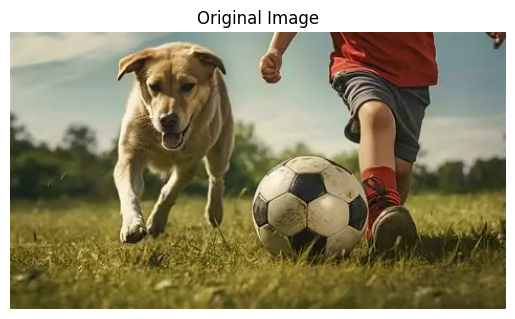

In [3]:
# Load Test Image

from PIL import Image
import matplotlib.pyplot as plt

img_path = 'image.png'
image = Image.open(img_path).convert("RGB")
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [6]:
# Image Captioning with BLIP

from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

inputs = blip_processor(image, return_tensors="pt")
caption_ids = blip_model.generate(**inputs)
caption = blip_processor.decode(caption_ids[0], skip_special_tokens=True)

print("BLIP Caption:", caption)

BLIP Caption: a small child running with a soccer ball [SEP]


In [7]:
# CLIP Embedding for Image and Caption

from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_inputs = clip_processor(text=[caption], images=image, return_tensors="pt", padding=True)
clip_outputs = clip_model(**clip_inputs)

image_emb = clip_outputs.image_embeds.detach().numpy()
text_emb = clip_outputs.text_embeds.detach().numpy()

CLIP Similarity Score (Image vs Caption): 0.2921


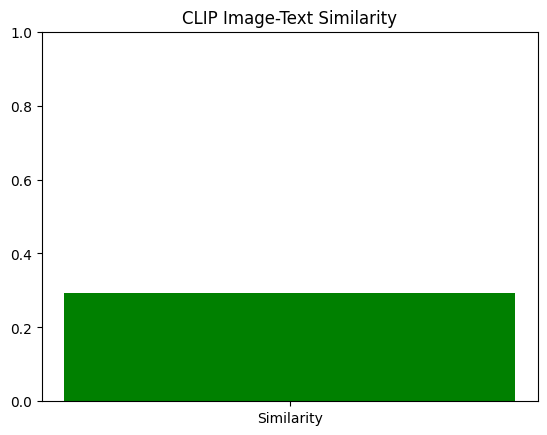

In [14]:
# Similarity Score Visualization

import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b.T) / (np.linalg.norm(a) * np.linalg.norm(b))

score = cosine_similarity(image_emb, text_emb)

# If score is a 1-element array, extract the scalar
score_value = float(score) if np.isscalar(score) else float(score[0][0])

print(f"CLIP Similarity Score (Image vs Caption): {score_value:.4f}")


# You can visualize this as a bar or gauge:
plt.bar(["Similarity"], [score_value], color='green')
plt.ylim(0, 1)
plt.title("CLIP Image-Text Similarity")
plt.show()


### ✅ Final Thoughts

This notebook gives you:
- BLIP caption quality check
- CLIP embedding alignment
- Semantic similarity score
- Visual feedback at each stage